# 04 — Erken Verim Tahmini

Sezonun ilk N günündeki veriyle yıl sonu `harvest_twso` tahmini.

**Kesim noktaları:** 30, 60, 90, 120. gün  
**Hedef:** Kaçıncı günde güvenilir tahmin yapılabiliyor?

In [9]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import duckdb
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path

from src.data.loader import RAW_PATH

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')
FIGS      = '../outputs/figures/'

CUTOFFS = [30, 60, 90, 120]

## 1. Kesim noktası bazında aggregate

Her sezon için `season_start` bulunur, ardından sadece ilk N günlük satırlar alınır.

In [10]:
def load_cutoff(n_days: int) -> pd.DataFrame:
    """İlk n_days günlük veriyi aggregate et."""
    return duckdb.query(f"""
        WITH season_start AS (
            SELECT
                latitude, longitude, elevation,
                crop_name, variety_name, year, wav_scenario, WAV,
                MIN(DATETIME::TIMESTAMP) AS start_ts,
                MAX(harvest_twso)        AS harvest_twso,
                MAX(sim_success)         AS sim_success
            FROM '{RAW_PATH}'
            GROUP BY latitude, longitude, elevation,
                     crop_name, variety_name, year, wav_scenario, WAV
        ),
        filtered AS (
            SELECT r.*
            FROM '{RAW_PATH}' r
            JOIN season_start s
              ON  r.latitude    = s.latitude
              AND r.longitude   = s.longitude
              AND r.crop_name   = s.crop_name
              AND r.year        = s.year
              AND r.wav_scenario= s.wav_scenario
            WHERE r.DATETIME::TIMESTAMP < s.start_ts + INTERVAL '{n_days} days'
        )
        SELECT
            f.latitude, f.longitude, f.elevation,
            f.crop_name, f.variety_name, f.year, f.wav_scenario, f.WAV,
            MAX(f.harvest_twso)   AS harvest_twso,
            MAX(f.sim_success)    AS sim_success,
            AVG(f.AIR_TEMP)       AS mean_temp,
            SUM(f.PRECIP)         AS total_precip,
            AVG(f.AIR_HUMIDITY)   AS mean_humidity,
            AVG(f.RFTRA)          AS mean_rftra,
            MAX(f.LAI)            AS max_lai,
            MAX(f.TAGP)           AS max_tagp,
            MAX(f.DVS)            AS max_dvs,
            COUNT(DISTINCT DATE_TRUNC('day', f.DATETIME::TIMESTAMP)) AS season_days
        FROM filtered f
        GROUP BY f.latitude, f.longitude, f.elevation,
                 f.crop_name, f.variety_name, f.year, f.wav_scenario, f.WAV
    """).df()

print('Fonksiyon hazır.')

Fonksiyon hazır.


In [11]:
datasets = {}
for n in CUTOFFS:
    print(f'Yükleniyor: ilk {n} gün...', end=' ')
    datasets[n] = load_cutoff(n)
    print(f'{len(datasets[n]):,} satır')

Yükleniyor: ilk 30 gün... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 satır
Yükleniyor: ilk 60 gün... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 satır
Yükleniyor: ilk 90 gün... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 satır
Yükleniyor: ilk 120 gün... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 satır


## 2. Feature engineering (her kesim noktası için)

In [12]:
TARGET = 'harvest_twso'
FEATURE_COLS = [
    'mean_temp', 'total_precip', 'mean_humidity', 'mean_rftra',
    'max_lai', 'max_tagp', 'max_dvs', 'season_days',
    'latitude', 'longitude', 'elevation', 'year', 'WAV', 'crop_te',
]

# Test yılları — 03 ile tutarlı
TEST_YEARS = [2023, 2024]

def prepare(df: pd.DataFrame):
    """Başarılı hasatları filtrele, target encode et, split yap."""
    df = df[df['sim_success'] == 1].copy()

    train = df[~df['year'].isin(TEST_YEARS)].copy()
    test  = df[ df['year'].isin(TEST_YEARS)].copy()

    # Target encoding — sadece train'den
    crop_mean = train.groupby('crop_name')[TARGET].mean().rename('crop_te')
    train = train.join(crop_mean, on='crop_name')
    test  = test.join(crop_mean, on='crop_name')
    test['crop_te'] = test['crop_te'].fillna(train[TARGET].mean())

    X_tr = train[FEATURE_COLS]
    y_tr = train[TARGET]
    X_te = test[FEATURE_COLS]
    y_te = test[TARGET]
    return X_tr, y_tr, X_te, y_te

print('Hazır.')

Hazır.


## 3. Model eğitimi (her kesim noktası)

In [13]:
results = {}

for n in CUTOFFS:
    X_tr, y_tr, X_te, y_te = prepare(datasets[n])

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )

    y_pred = model.predict(X_te)
    rmse = root_mean_squared_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    mae  = np.mean(np.abs(y_te - y_pred))

    results[n] = {'rmse': rmse, 'mae': mae, 'r2': r2,
                  'best_iter': model.best_iteration_,
                  'model': model, 'y_te': y_te, 'y_pred': y_pred}
    print(f'Day {n:3d} | R²={r2:.4f}  RMSE={rmse:,.0f}  MAE={mae:,.0f}  iter={model.best_iteration_}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 889
[LightGBM] [Info] Number of data points in the train set: 34013, number of used features: 9
[LightGBM] [Info] Start training from score 2049.027386
Day  30 | R²=0.7170  RMSE=1,545  MAE=912  iter=198
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000569 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1598
[LightGBM] [Info] Number of data points in the train set: 34013, number of used features: 13
[LightGBM] [Info] Start training from score 2049.027386
Day  60 | R²=0.7531  RMSE=1,444  MAE=873  iter=96
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing w

## 4. Karşılaştırma grafiği

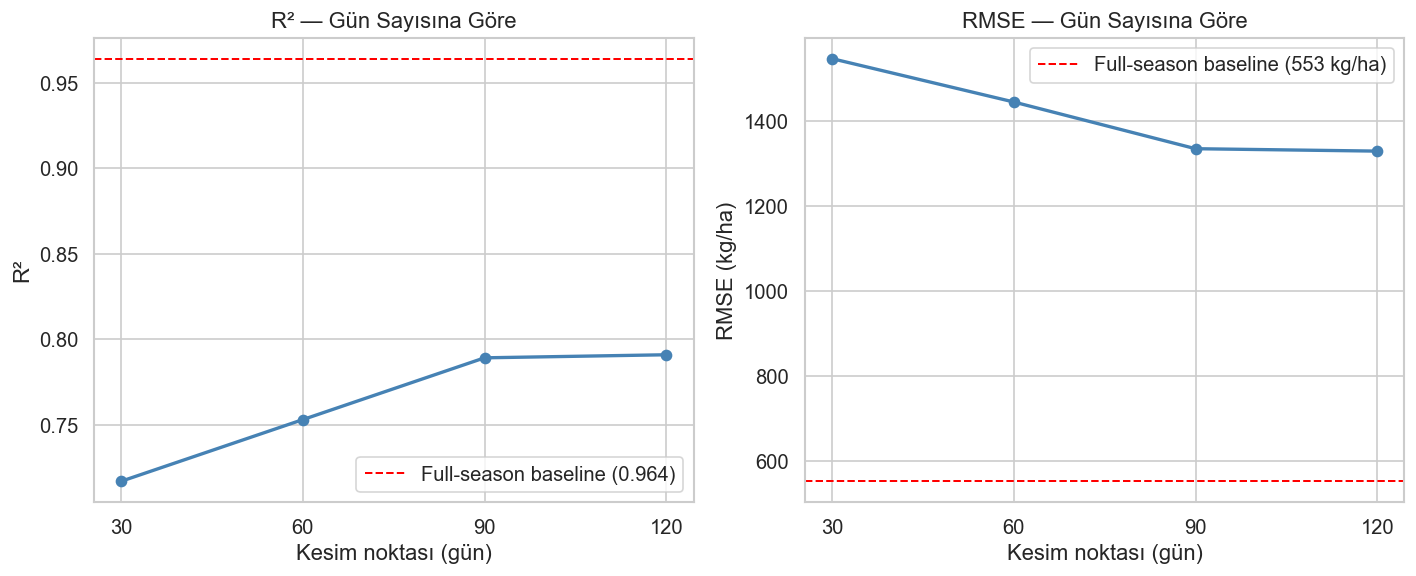

In [14]:
# 03'teki full-season baseline
BASELINE = {'r2': 0.964, 'rmse': 553}

days  = CUTOFFS
r2s   = [results[n]['r2']   for n in days]
rmses = [results[n]['rmse'] for n in days]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(days, r2s, marker='o', color='steelblue', lw=2)
axes[0].axhline(BASELINE['r2'], ls='--', color='red', lw=1.2, label=f'Full-season baseline ({BASELINE["r2"]})')
axes[0].set_xlabel('Kesim noktası (gün)')
axes[0].set_ylabel('R²')
axes[0].set_title('R² — Gün Sayısına Göre')
axes[0].legend()
axes[0].set_xticks(days)

axes[1].plot(days, rmses, marker='o', color='steelblue', lw=2)
axes[1].axhline(BASELINE['rmse'], ls='--', color='red', lw=1.2, label=f'Full-season baseline ({BASELINE["rmse"]} kg/ha)')
axes[1].set_xlabel('Kesim noktası (gün)')
axes[1].set_ylabel('RMSE (kg/ha)')
axes[1].set_title('RMSE — Gün Sayısına Göre')
axes[1].legend()
axes[1].set_xticks(days)

plt.tight_layout()
plt.savefig(FIGS + 'early_prediction_comparison.png', bbox_inches='tight')
plt.show()

## 5. Tahmin vs Gerçek (4 panel)

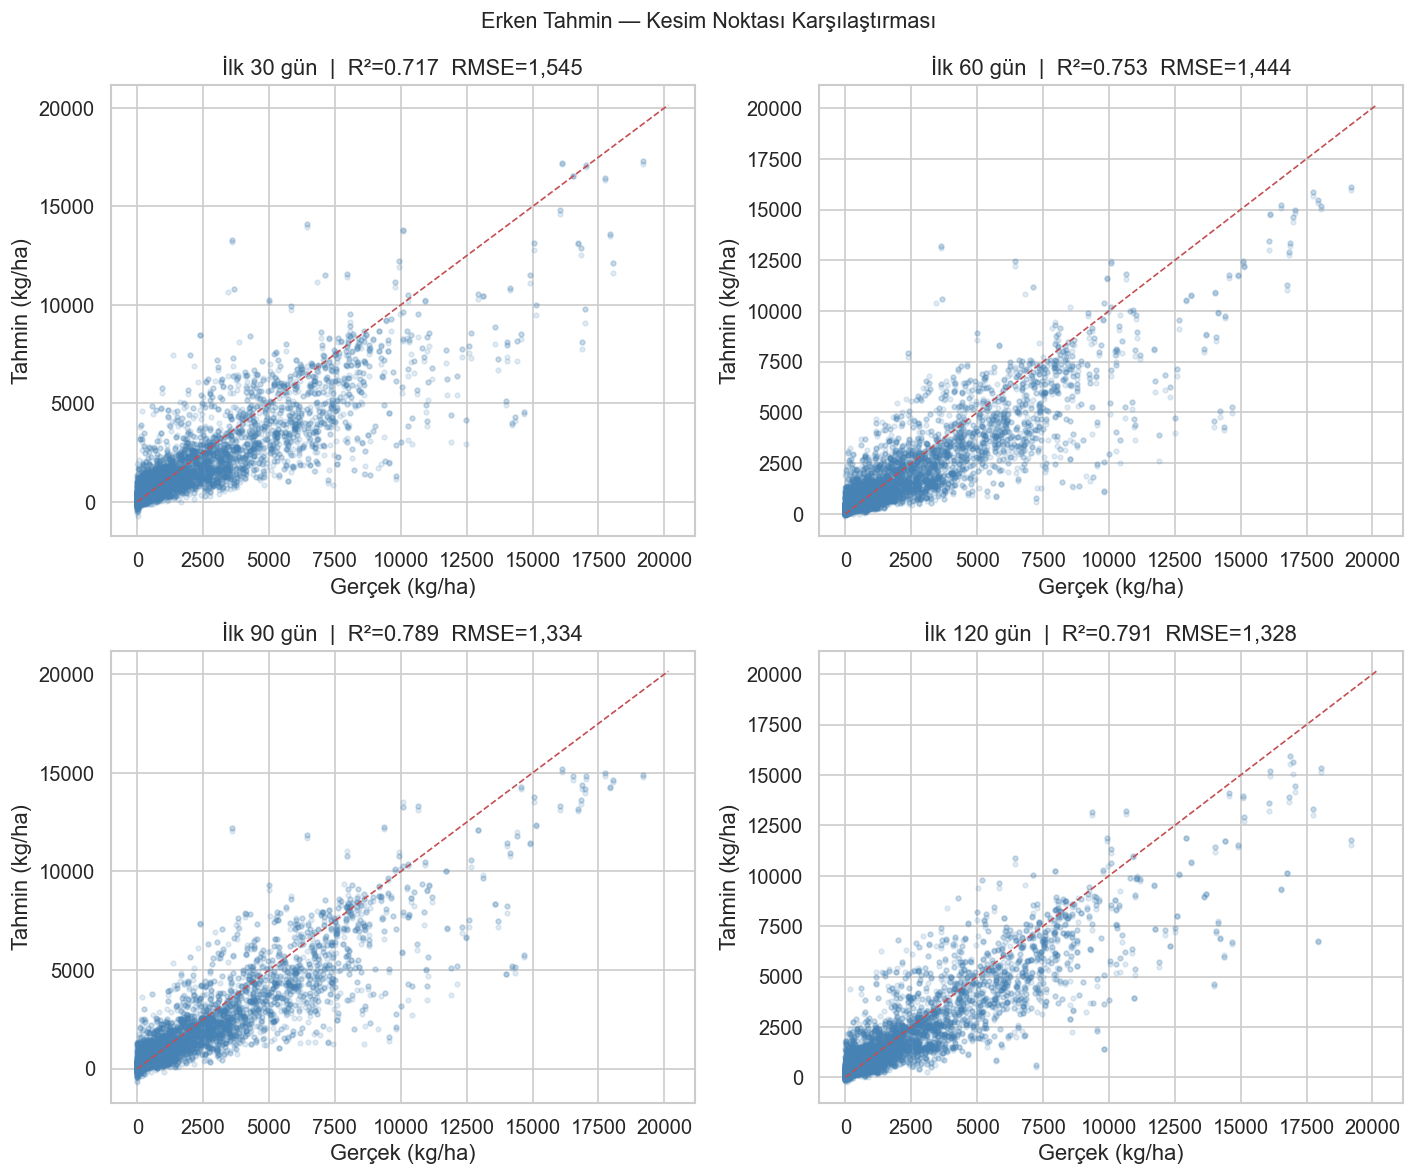

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, n in zip(axes.flat, CUTOFFS):
    y_te   = results[n]['y_te']
    y_pred = results[n]['y_pred']
    r2     = results[n]['r2']
    rmse   = results[n]['rmse']

    ax.scatter(y_te, y_pred, alpha=0.15, s=8, color='steelblue')
    lim = max(y_te.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1)
    ax.set_title(f'İlk {n} gün  |  R²={r2:.3f}  RMSE={rmse:,.0f}')
    ax.set_xlabel('Gerçek (kg/ha)')
    ax.set_ylabel('Tahmin (kg/ha)')

plt.suptitle('Erken Tahmin — Kesim Noktası Karşılaştırması', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS + 'early_prediction_scatter.png', bbox_inches='tight')
plt.show()

## 6. Sonuçları kaydet

In [16]:
import json

summary = {
    str(n): {'r2': round(results[n]['r2'], 4),
             'rmse': round(results[n]['rmse'], 2),
             'mae': round(results[n]['mae'], 2),
             'best_iter': results[n]['best_iter']}
    for n in CUTOFFS
}
summary['full_season_baseline'] = BASELINE

with open(OUTPUTS / 'early_prediction_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "30": {
    "r2": 0.717,
    "rmse": 1545.46,
    "mae": 912.08,
    "best_iter": 198
  },
  "60": {
    "r2": 0.7531,
    "rmse": 1443.68,
    "mae": 872.97,
    "best_iter": 96
  },
  "90": {
    "r2": 0.7892,
    "rmse": 1333.98,
    "mae": 773.93,
    "best_iter": 635
  },
  "120": {
    "r2": 0.791,
    "rmse": 1328.32,
    "mae": 798.35,
    "best_iter": 124
  },
  "full_season_baseline": {
    "r2": 0.964,
    "rmse": 553
  }
}


In [17]:
import joblib

MODELS_DIR = OUTPUTS / "models"
MODELS_DIR.mkdir(exist_ok=True)

for n in CUTOFFS:
    path = MODELS_DIR / f"early_lgbm_day{n}.joblib"
    joblib.dump(results[n]["model"], path)
    print(f"Kaydedildi: {path}")


Kaydedildi: ../outputs/models/early_lgbm_day30.joblib
Kaydedildi: ../outputs/models/early_lgbm_day60.joblib
Kaydedildi: ../outputs/models/early_lgbm_day90.joblib
Kaydedildi: ../outputs/models/early_lgbm_day120.joblib
